In [5]:
# load librairies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from os.path import join
import seaborn as sns
import statsmodels.api as sm
import scipy
import json
import statsmodels.formula.api as smf
from collections import defaultdict
from scipy.stats import wilcoxon, ttest_rel

from functions import utils
from functions import plotting
from functions import io

# 1. Load subjects #

In [6]:
# Use the Included or excluded.xlsx document:
onedrive_path = utils._get_onedrive_path()

working_path = os.path.dirname(os.getcwd())
results_path = join(working_path, "results")
behav_results_saving_path = join(results_path, "behav_results")
if not os.path.isdir(behav_results_saving_path):
    os.makedirs(behav_results_saving_path)

In [8]:
# read the json file containing the included and excluded subjects
# Open and read the JSON file
included_excluded_file = join(results_path, 'final_included_subjects.json')
with open(included_excluded_file, 'r') as file:
    included_subjects = json.load(file)

In [ ]:
included_subjects

['C003', 'C004', 'C006', 'C007', 'C008', 'C009', 'C010', 'C011', 'C012', 'sub006', 'sub011', 'sub015', 'sub019', 'sub023', 'sub025', 'sub027', 'sub028', 'sub029', 'sub032', 'sub033']


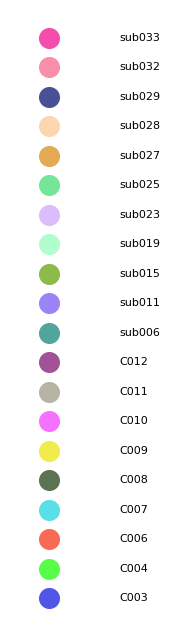

In [9]:
subject_colors = utils.create_color_palette(included_subjects)
utils.plot_color_palette(subject_colors)

In [10]:
data = io.load_behav_data(included_subjects, onedrive_path)

C003 mSST
C004 mSST
C006 mSST
C007 mSST
C008 mSST
C009 mSST
C010 mSST
C011 mSST
C012 mSST
sub006 DBS ON mSST
sub006 DBS OFF mSST
sub011 DBS OFF mSST
sub011 DBS ON mSST
sub015 DBS OFF mSST
sub015 DBS ON mSST
sub019 DBS ON mSST
sub019 DBS OFF mSST
sub023 DBS OFF mSST
sub023 DBS ON mSST
sub025 DBS ON mSST
sub025 DBS OFF mSST
sub027 DBS ON mSST
sub027 DBS OFF mSST
sub028 DBS OFF mSST
sub028 DBS ON mSST
sub029 DBS ON mSST
sub029 DBS OFF mSST
sub032 DBS ON mSST
sub032 DBS OFF mSST
sub033 DBS ON mSST
sub033 DBS OFF mSST


In [11]:
stats = utils.extract_stats(data)

In [ ]:
stats

In [12]:
mean_RT_dict = {}
for subject in included_subjects:
    mean_RT_dict[subject] = {
        'go_trial': stats[subject]['go_trial mean RT (ms)']/1000,
        'go_fast_trial': stats[subject]['go_fast_trial mean RT (ms)']/1000,
        'go_continue_trial': stats[subject]['go_continue_trial mean RT (ms)']/1000,
        'stop_trial' : stats[subject]['stop_trial mean RT (ms)']/1000
    }

In [ ]:
mean_RT_dict

In [13]:
# for each subject, save in a dictionary a dataframe containing only stop_trials and the following trial
stop_data = {}
data_after_successful_stop = {}
data_after_unsuccessful_stop = {}
for subject in included_subjects:
    subject_data = data[subject]
    # only keep rows from the main experiment (from the first row where 'blocks.thisRepN' is not NaN)
    subject_data = subject_data[subject_data['blocks.thisRepN'].notna()]
    # only keep the columns of interest
    subject_data = subject_data[['trial_type', 'early_press_resp.corr', 'stop_signal_time', 'key_resp_experiment.corr', 'key_resp_experiment.rt']]
    stop_trials = subject_data[subject_data['trial_type'] == 'stop_trial']
    stop_trials_success = stop_trials[stop_trials['key_resp_experiment.corr'] == 1]
    stop_trials_unsuccess = stop_trials[stop_trials['key_resp_experiment.corr'] == 0]
    # check if the stop trial is not the last trial for each
    stop_trials_success = stop_trials_success[stop_trials_success.index < len(subject_data) - 1]
    following_trials_after_success = subject_data.iloc[stop_trials_success.index + 1]
    stop_trials_unsuccess = stop_trials_unsuccess[stop_trials_unsuccess.index < len(subject_data) - 1]
    following_trials_after_unsuccess = subject_data.iloc[stop_trials_unsuccess.index + 1]
    stop_data[subject] = stop_trials
    data_after_successful_stop[subject] = following_trials_after_success
    data_after_unsuccessful_stop[subject] = following_trials_after_unsuccess



In [14]:
# get number of early presses after successful and unsuccessful stop trials
early_presses_after_successful = {}
early_presses_after_unsuccessful = {}
for subject in included_subjects:
    early_presses_after_successful[subject] = data_after_successful_stop[subject]['early_press_resp.corr'].sum()
    early_presses_after_unsuccessful[subject] = data_after_unsuccessful_stop[subject]['early_press_resp.corr'].sum()

print(f'Early press after successful stop: {early_presses_after_successful}')
print(f'Early press after unsuccessful stop: {early_presses_after_unsuccessful}')

Early press after successful stop: {'C003 mSST': 0.0, 'C004 mSST': 0.0, 'C006 mSST': 0.0, 'C007 mSST': 0.0, 'C008 mSST': 0.0, 'C009 mSST': 0.0, 'C010 mSST': 0.0, 'C011 mSST': 0.0, 'C012 mSST': 0.0, 'sub006 DBS ON mSST': 0.0, 'sub006 DBS OFF mSST': 0.0, 'sub011 DBS OFF mSST': 0.0, 'sub011 DBS ON mSST': 0.0, 'sub015 DBS OFF mSST': 0.0, 'sub015 DBS ON mSST': 0.0, 'sub019 DBS ON mSST': 0.0, 'sub019 DBS OFF mSST': 0.0, 'sub023 DBS OFF mSST': 1.0, 'sub023 DBS ON mSST': 0.0, 'sub025 DBS ON mSST': 1.0, 'sub025 DBS OFF mSST': 1.0, 'sub027 DBS ON mSST': 0.0, 'sub027 DBS OFF mSST': 0.0, 'sub028 DBS OFF mSST': 0.0, 'sub028 DBS ON mSST': 0.0, 'sub029 DBS ON mSST': 0.0, 'sub029 DBS OFF mSST': 0.0, 'sub032 DBS ON mSST': 0.0, 'sub032 DBS OFF mSST': 0.0, 'sub033 DBS ON mSST': 0.0, 'sub033 DBS OFF mSST': 0.0}
Early press after unsuccessful stop: {'C003 mSST': 0.0, 'C004 mSST': 0.0, 'C006 mSST': 0.0, 'C007 mSST': 0.0, 'C008 mSST': 0.0, 'C009 mSST': 0.0, 'C010 mSST': 0.0, 'C011 mSST': 0.0, 'C012 mSST': 0.

In [15]:
# get mean RT after unsuccessful stop for each trial type
subdivided_data_unsuccessful = {}
subdivided_data_successful = {}
for subject in included_subjects:
    subject_data = data_after_unsuccessful_stop[subject]
    unsuccessful_following = {}
    unsuccessful_following['go_trial'] = subject_data[subject_data['trial_type'] == 'go_trial']
    unsuccessful_following['stop_trial'] = subject_data[subject_data['trial_type'] == 'stop_trial']
    unsuccessful_following['go_fast_trial'] = subject_data[subject_data['trial_type'] == 'go_fast_trial']
    unsuccessful_following['go_continue_trial'] = subject_data[subject_data['trial_type'] == 'go_continue_trial']
    subdivided_data_unsuccessful[subject] = unsuccessful_following

    subject_data = data_after_successful_stop[subject]
    successful_following = {}
    successful_following['go_trial'] = subject_data[subject_data['trial_type'] == 'go_trial']
    successful_following['stop_trial'] = subject_data[subject_data['trial_type'] == 'stop_trial']
    successful_following['go_fast_trial'] = subject_data[subject_data['trial_type'] == 'go_fast_trial']
    successful_following['go_continue_trial'] = subject_data[subject_data['trial_type'] == 'go_continue_trial']
    subdivided_data_successful[subject] = successful_following
    


In [ ]:
subdivided_data_unsuccessful['C003 mSST']['go_trial']['key_resp_experiment.rt'].mean()

In [ ]:
subdivided_data_successful['C003 mSST']['go_trial']['key_resp_experiment.rt'].mean()

In [16]:
control_sub = [i for i in included_subjects if i.startswith('C')]
dbson_sub = [i for i in included_subjects if i.startswith('sub') and 'DBS ON' in i]
dbsoff_sub = [i for i in included_subjects if i.startswith('sub') and 'DBS OFF' in i]
pop_dict = {'control': control_sub, 'dbson': dbson_sub, 'dbsoff': dbsoff_sub}


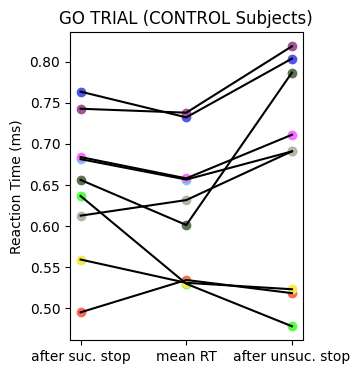

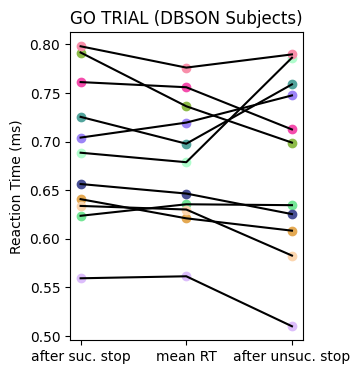

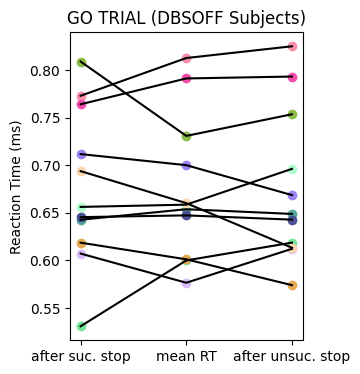

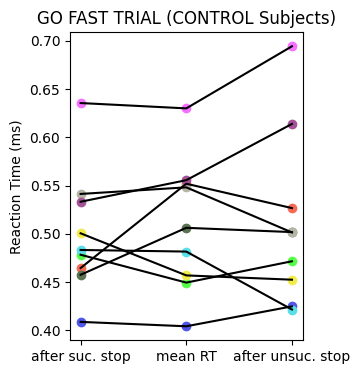

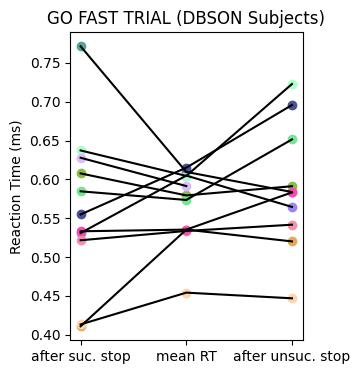

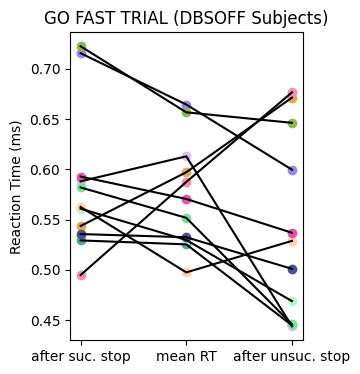

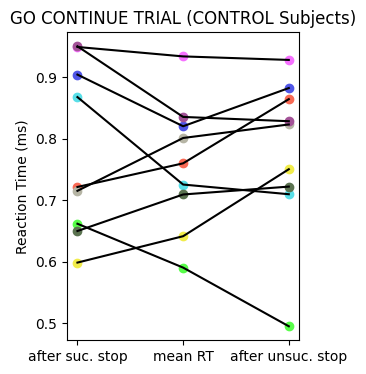

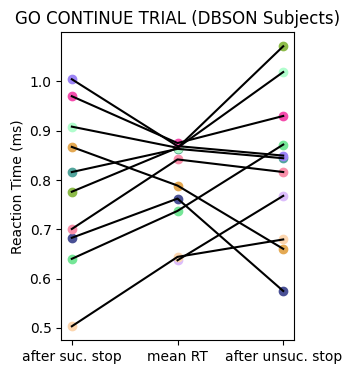

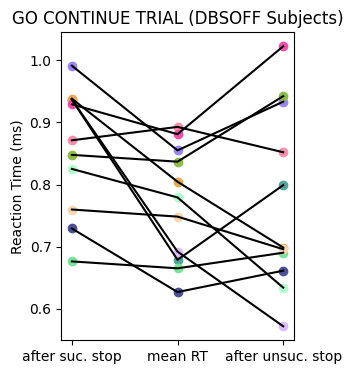

In [17]:
# plot rt after successful and unsuccessful stop trials
trial_types = ['go_trial', 'go_fast_trial', 'go_continue_trial']
for trial_type in trial_types:
    for key, value in pop_dict.items():
        plt.figure(figsize=(3, 4))
        rt_after_successful = []
        rt_after_unsuccessful = []
        for subject in value:
            rt_after_successful.append(subdivided_data_successful[subject][trial_type]['key_resp_experiment.rt'].mean())
            rt_after_unsuccessful.append(subdivided_data_unsuccessful[subject][trial_type]['key_resp_experiment.rt'].mean())                 
            plt.plot([1], subdivided_data_successful[subject][trial_type]['key_resp_experiment.rt'].mean(), 'o', color= subject_colors[subject.split()[0] ])
            plt.plot([3], subdivided_data_unsuccessful[subject][trial_type]['key_resp_experiment.rt'].mean(), 'o', color= subject_colors[subject.split()[0] ])
            plt.plot([2], mean_RT_dict[subject][trial_type], 'o', color= subject_colors[subject.split()[0] ])
        for i in range(len(value)):
            plt.plot([1, 2, 3], [rt_after_successful[i], mean_RT_dict[value[i]][trial_type], rt_after_unsuccessful[i]], 'k-')  
        plt.xticks([1, 2, 3], ['after suc. stop', 'mean RT', 'after unsuc. stop'])
        plt.ylabel('Reaction Time (ms)')
        plt.title(f'{trial_type.replace("_", " ").upper()} ({key.upper()} Subjects)')
        plt.show()


### replicate classification from Li CS, Huang C, Yan P, Paliwal P, Constable RT, Sinha R. Neural correlates of post-error slowing during a stop signal task: a functional magnetic resonance imaging study. J Cogn Neurosci. 2008 Jun;20(6):1021-9. doi: 10.1162/jocn.2008.20071. PMID: 18211230; PMCID: PMC2597347.###

Classify each GO trial with a RT into:
- pG (post successful GO)
- pSS (post successful STOP)
- pSE (post unsuccessful STOP)

Do the same but separately for GF/GC trials?

In [18]:
mini_data = {}
for subject in included_subjects:
    subject_data = data[subject]
    # only keep rows from the main experiment (from the first row where 'blocks.thisRepN' is not NaN)
    subject_data = subject_data[subject_data['blocks.thisRepN'].notna()]
    mini_data[subject] = subject_data[['trial_type', 'early_press_resp.corr', 'stop_signal_time', 'key_resp_experiment.corr', 'key_resp_experiment.rt']]

In [19]:
for subject in included_subjects:
    sub_data = mini_data[subject]
    # create an empty list to store the new column resulting from the operation
    post = []
    for i in range(len(sub_data)):
        if i == 0:
            post.append(np.nan)  # first trial has no previous trial
        else:
            if sub_data.iloc[i]['trial_type'] == 'go_trial':
                prev_trial = sub_data.iloc[i - 1]
                if prev_trial['trial_type'] == 'stop_trial' and prev_trial['key_resp_experiment.corr'] == 0:
                    post.append('pSE')
                elif prev_trial['trial_type'] == 'stop_trial' and prev_trial['key_resp_experiment.corr'] == 1:
                    post.append('pSS')
                elif prev_trial['trial_type'] == 'go_fast_trial' and prev_trial['key_resp_experiment.corr'] == 1:
                    post.append('pGF')
                elif prev_trial['trial_type'] == 'go_continue_trial' and prev_trial['key_resp_experiment.corr'] == 1:
                    post.append('pGC')
                elif prev_trial['trial_type'] == 'go_trial' and prev_trial['key_resp_experiment.corr'] == 1:
                    post.append('pG')
                else:
                    post.append(np.nan)
            else:
                post.append(np.nan)
    sub_data['post'] = post
    mini_data[subject] = sub_data

C:\Users\Juliette\AppData\Local\Temp\ipykernel_15744\1762000982.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_data['post'] = post


In [ ]:
mini_data.keys()

In [20]:
mini_data['C003 mSST'][0:40]

,trial_type,early_press_resp.corr,stop_signal_time,key_resp_experiment.corr,key_resp_experiment.rt,post
38,stop_trial,0.0,0.125,1.0,NaN,NaN
39,go_continue_trial,0.0,NaN,1.0,0.570173,NaN
40,go_trial,0.0,NaN,1.0,0.621220,pGC
41,go_trial,0.0,NaN,1.0,0.339435,pG
42,go_trial,0.0,NaN,1.0,0.328407,pG
43,go_fast_trial,0.0,NaN,1.0,0.326239,NaN
44,go_trial,0.0,NaN,1.0,0.468939,pGF
45,stop_trial,0.0,0.075,1.0,NaN,NaN
46,go_trial,0.0,NaN,1.0,0.315489,pSS
47,go_continue_trial,0.0,NaN,1.0,0.539518,NaN


In [21]:
# create a new column to discriminate pSSi from pSSni and pSEi from pSEni. Rule is:
# if pSS/pSE RT > RT from all previous pG, then pSSi/pSEi
# if pSS/pSE RT < RT from all previous pG, then pSSni/pSEni

for subject in included_subjects:
    sub_data = mini_data[subject]
    # create an empty list to store the new column resulting from the operation
    post_increase_notincreased = np.empty(len(sub_data), dtype=object).tolist()
    print(len(sub_data))
    for i in range(len(sub_data)):
        # print(sub_data.iloc[i]['post'])
        if sub_data.iloc[i]['post'] == 'pSS':
            current_rt = sub_data.iloc[i]['key_resp_experiment.rt']
            previous_pG_rts = sub_data[(sub_data.index < i) & (sub_data['post'] == 'pG')]['key_resp_experiment.rt']
            if len(previous_pG_rts) == 0:
                continue  # no previous pG trials to compare with
            if current_rt > np.nanmean(previous_pG_rts):
                post_increase_notincreased[i] = 'pSSi'
            else:
                post_increase_notincreased[i] = 'pSSni'
        elif sub_data.iloc[i]['post'] == 'pSE':
            current_rt = sub_data.iloc[i]['key_resp_experiment.rt']
            previous_pG_rts = sub_data[(sub_data.index < i) & (sub_data['post'] == 'pG')]['key_resp_experiment.rt']
            if len(previous_pG_rts) == 0:
                continue  # no previous pG trials to compare with
            if current_rt > np.nanmean(previous_pG_rts):
                post_increase_notincreased[i] = 'pSEi'
            else:
                post_increase_notincreased[i] = 'pSEni'
        # else:
        #     post_increase_notincreased[i] = np.nan
    print(len(post_increase_notincreased))
    sub_data['i_ni'] = post_increase_notincreased
    mini_data[subject] = sub_data


480
480
360
360
480
480
360
360
360


C:\Users\Juliette\AppData\Local\Temp\ipykernel_15744\1749176596.py:26: RuntimeWarning: Mean of empty slice
  if current_rt > np.nanmean(previous_pG_rts):


360
360
360
360
360
360
360
360
360
480
480
360
360
480
480
360
360
480
480
360
360
480
480
360
360
360
360
360
360
360
360
360
360
360
360
360
360
360
360
360
360
360
360
360
360
360
360
360
360
360
360
360
360


C:\Users\Juliette\AppData\Local\Temp\ipykernel_15744\1749176596.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_data['i_ni'] = post_increase_notincreased


In [71]:
mini_data['C010 mSST']['post']

39     NaN
40     NaN
41     pGF
42      pG
43     NaN
      ... 
394    pGC
395     pG
396    NaN
397    NaN
398    pSS
Name: post, Length: 360, dtype: object

In [72]:
values = mini_data['sub006 DBS OFF mSST']['i_ni'].value_counts()

In [22]:
all_pSEi = []
all_pSEni = []
all_pSSi = []
all_pSSni = []
all_sub_dict_i_ni = {}  
for subject in included_subjects:
    sub_dict = {}
    values = mini_data[subject]['i_ni'].value_counts()
    if 'pSEi' in values:
        all_pSEi.append(values['pSEi'])
        sub_dict['pSEi'] = values['pSEi']
    else:
        all_pSEi.append(np.nan)
        sub_dict['pSEi'] = 0
    if 'pSEni' in values:
        all_pSEni.append(values['pSEni'])
        sub_dict['pSEni'] = values['pSEni']
    else:
        all_pSEni.append(np.nan)
        sub_dict['pSEni'] = 0
    if 'pSSi' in values:
        all_pSSi.append(values['pSSi'])
        sub_dict['pSSi'] = values['pSSi']
    else:
        all_pSSi.append(np.nan)
        sub_dict['pSSi'] = 0
    if 'pSSni' in values:
        all_pSSni.append(values['pSSni'])
        sub_dict['pSSni'] = values['pSSni']
    else:
        all_pSSni.append(np.nan)
        sub_dict['pSSni'] = 0
    all_sub_dict_i_ni[subject] = sub_dict

In [23]:
# extract same values but in percent:
all_pSEi_percent = []
all_pSEni_percent = []
all_pSSi_percent = []
all_pSSni_percent = []
all_sub_dict_i_ni_percent = {}  
for subject in included_subjects:
    sub_dict = {}
    values = mini_data[subject]['i_ni'].value_counts()
    if 'pSEi' in values:
        if 'pSEni' in values:
            total_pSE = values['pSEi'] + values['pSEni']
        else:
            total_pSE = values['pSEi']
        all_pSEi_percent.append((values['pSEi'] / total_pSE) * 100)
        sub_dict['pSEi'] = (values['pSEi'] / total_pSE) * 100
    else:
        all_pSEi_percent.append(0)
        sub_dict['pSEi'] = 0
    if 'pSEni' in values:
        if 'pSEi' in values:
            total_pSE = values['pSEi'] + values['pSEni']
        else:
            total_pSE = values['pSEni']
        all_pSEni_percent.append((values['pSEni'] / total_pSE) * 100)
        sub_dict['pSEni'] = (values['pSEni'] / total_pSE) * 100
    else:
        all_pSEni_percent.append(0)
        sub_dict['pSEni'] = 0
    if 'pSSi' in values:
        if 'pSSni' in values:
            total_pSS = values['pSSi'] + values['pSSni']
        else:
            total_pSS = values['pSSi']
        all_pSSi_percent.append((values['pSSi'] / total_pSS) * 100)
        sub_dict['pSSi'] = (values['pSSi'] / total_pSS) * 100
    else:
        all_pSSi_percent.append(0)
        sub_dict['pSSi'] = 0
    if 'pSSni' in values:
        if 'pSSi' in values:
            total_pSS = values['pSSi'] + values['pSSni']
        else:
            total_pSS = values['pSSni']
        all_pSSni_percent.append((values['pSSni'] / total_pSS) * 100)
        sub_dict['pSSni'] = (values['pSSni'] / total_pSS) * 100
    else:
        all_pSSni_percent.append(0)
        sub_dict['pSSni'] = 0
    all_sub_dict_i_ni_percent[subject] = sub_dict

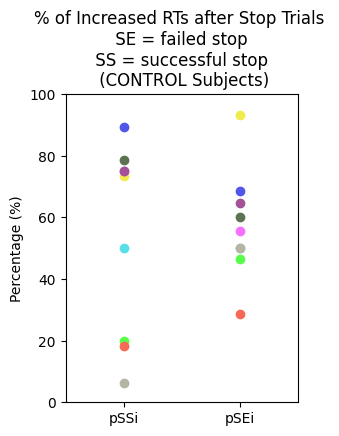

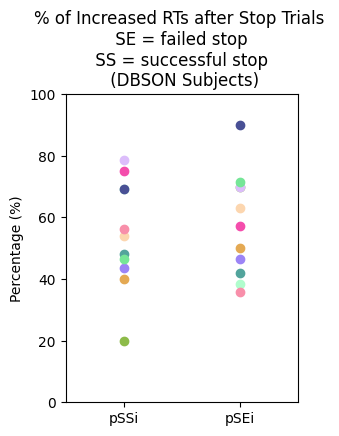

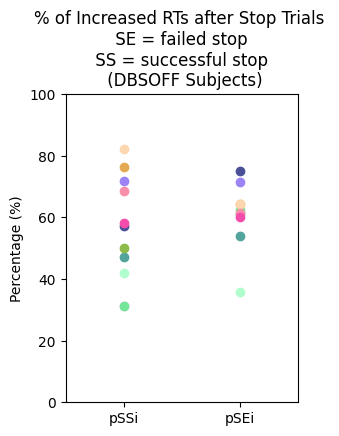

In [24]:
# divide subjects in populations
control_sub = [i for i in included_subjects if i.startswith('C')]
dbson_sub = [i for i in included_subjects if i.startswith('sub') and 'DBS ON' in i]
dbsoff_sub = [i for i in included_subjects if i.startswith('sub') and 'DBS OFF' in i]
pop_dict = {'control': control_sub, 'dbson': dbson_sub, 'dbsoff': dbsoff_sub}

# plot percentage of i vs ni for each population
for key, value in pop_dict.items():
    plt.figure(figsize=(3, 4))
    pSEi_percent = []
    # pSEni_percent = []
    pSSi_percent = []
    # pSSni_percent = []
    for subject in value:
        pSEi_percent.append(all_sub_dict_i_ni_percent[subject]['pSEi'])
        # pSEni_percent.append(all_sub_dict_i_ni_percent[subject]['pSEni'])
        pSSi_percent.append(all_sub_dict_i_ni_percent[subject]['pSSi'])
        # pSSni_percent.append(all_sub_dict_i_ni_percent[subject]['pSSni'])
        # plt.plot(['pSEi', 'pSSi'], [pSEi_percent,pSSi_percent], 'o-', color=subject_colors[subject.split()[0]])
        plt.plot([2], all_sub_dict_i_ni_percent[subject]['pSEi'], 'o', color= subject_colors[subject.split()[0]])
        plt.plot([1], all_sub_dict_i_ni_percent[subject]['pSSi'], 'o', color= subject_colors[subject.split()[0]])
    # plot barplot with seaborn
    df_plot = pd.DataFrame({
        'pSEi': pSEi_percent,
        # 'pSEni': pSEni_percent,
        'pSSi': pSSi_percent,
    #     'pSSni': pSSni_percent
    })
        
    df_melted = df_plot.melt(var_name='Condition', value_name='Percentage')
    # sns.barplot(x='Condition', y='Percentage', data=df_melted, errorbar='sd', palette='pastel')
    # plt.plot(['pSEi', 'pSSi'], [pSEi_percent, pSSi_percent], 'o-', color=subject_colors[subject.split()[0]])
    plt.title(f'% of Increased RTs after Stop Trials \n SE = failed stop \n SS = successful stop \n ({key.upper()} Subjects)')
    plt.ylabel('Percentage (%)')
    plt.xticks([1, 2], ['pSSi', 'pSEi'])
    plt.xlim(0.5, 2.5)
    # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0, 100)
    plt.show()

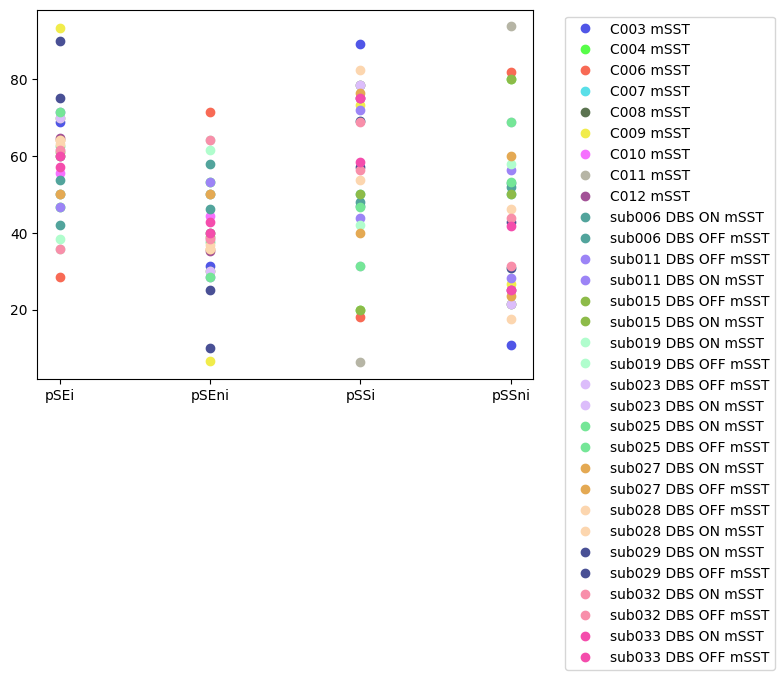

In [25]:
for key, value in all_sub_dict_i_ni_percent.items():
    plt.plot(value.keys(), value.values(), 'o', color = subject_colors[key.split()[0]])

plt.legend(all_sub_dict_i_ni_percent.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')

In [75]:
all_sub_dict_i_ni

{'C003 mSST': {'pSEi': 11, 'pSEni': 5, 'pSSi': 25, 'pSSni': 3},
 'C004 mSST': {'pSEi': 7, 'pSEni': 8, 'pSSi': 3, 'pSSni': 12},
 'C006 mSST': {'pSEi': 6, 'pSEni': 15, 'pSSi': 4, 'pSSni': 18},
 'C007 mSST': {'pSEi': 4, 'pSEni': 4, 'pSSi': 8, 'pSSni': 8},
 'C008 mSST': {'pSEi': 6, 'pSEni': 4, 'pSSi': 11, 'pSSni': 3},
 'C009 mSST': {'pSEi': 14, 'pSEni': 1, 'pSSi': 11, 'pSSni': 4},
 'C010 mSST': {'pSEi': 5, 'pSEni': 4, 'pSSi': 15, 'pSSni': 5},
 'sub006 DBS ON mSST': {'pSEi': 8, 'pSEni': 11, 'pSSi': 12, 'pSSni': 13},
 'sub006 DBS OFF mSST': {'pSEi': 7, 'pSEni': 6, 'pSSi': 8, 'pSSni': 9},
 'sub011 DBS OFF mSST': {'pSEi': 10, 'pSEni': 4, 'pSSi': 23, 'pSSni': 9},
 'sub011 DBS ON mSST': {'pSEi': 7, 'pSEni': 8, 'pSSi': 7, 'pSSni': 9},
 'sub015 DBS OFF mSST': {'pSEi': 11, 'pSEni': 7, 'pSSi': 13, 'pSSni': 13},
 'sub015 DBS ON mSST': {'pSEi': 7, 'pSEni': 3, 'pSSi': 3, 'pSSni': 12},
 'sub019 DBS ON mSST': {'pSEi': 5, 'pSEni': 8, 'pSSi': 18, 'pSSni': 8},
 'sub019 DBS OFF mSST': {'pSEi': 5, 'pSEni': 9,

In [24]:
# extract RT of go_trials that are pG, pSS, and pSE
pG_RT_all = {}
pSS_RT_all = {}
pSE_RT_all = {}
for subject in included_subjects:
    sub_data = mini_data[subject]
    pG_trials = sub_data[(sub_data['post'] == 'pG')]
    pG_RT_all[subject] = pG_trials['key_resp_experiment.rt'].tolist()
    pSS_trials = sub_data[(sub_data['post'] == 'pSS')]
    pSS_RT_all[subject] = pSS_trials['key_resp_experiment.rt'].tolist()
    pSE_trials = sub_data[(sub_data['post'] == 'pSE')]
    pSE_RT_all[subject] = pSE_trials['key_resp_experiment.rt'].tolist()


In [25]:
np.nanmean(pG_RT_all['C003 mSST'])

0.737194075000987

In [26]:
np.nanmean(pSS_RT_all['C003 mSST'])

0.6629350903226183

In [27]:
np.nanmean(pSE_RT_all['C003 mSST'])

0.7260153187526157

In [28]:
mean_pG_RT = {}
mean_pSS_RT = {}
mean_pSE_RT = {}
for subject in included_subjects:
    mean_pG_RT[subject] = np.nanmean(pG_RT_all[subject])
    mean_pSS_RT[subject] = np.nanmean(pSS_RT_all[subject])
    mean_pSE_RT[subject] = np.nanmean(pSE_RT_all[subject])

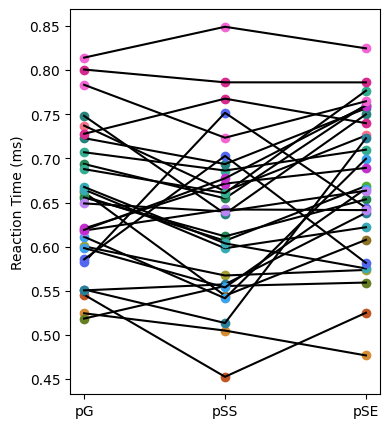

In [29]:
# plot mean RT for pG, pSS, pSE
conditions = ['pG', 'pSS', 'pSE']
plt.figure(figsize=(4, 5))
for subject in included_subjects:
    plt.plot([1], mean_pG_RT[subject], 'o', color= subject_colors[subject.split()[0] ])
    plt.plot([2], mean_pSS_RT[subject], 'o', color= subject_colors[subject.split()[0] ])
    plt.plot([3], mean_pSE_RT[subject], 'o', color= subject_colors[subject.split()[0] ])
    plt.plot([1, 2, 3], [mean_pG_RT[subject], mean_pSS_RT[subject], mean_pSE_RT[subject]], 'k-')  
plt.xticks([1, 2, 3], ['pG', 'pSS', 'pSE'])
plt.ylabel('Reaction Time (ms)')
# plt.title(f'Mean RT after trial type ({key.upper()} Subjects)')
plt.show()

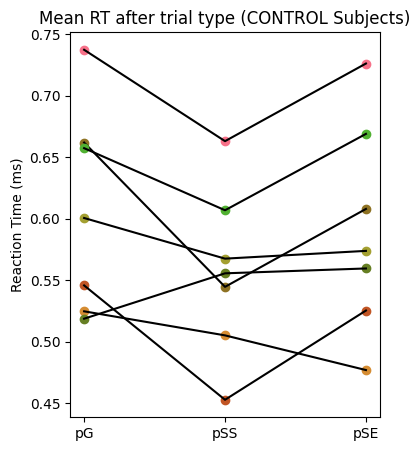

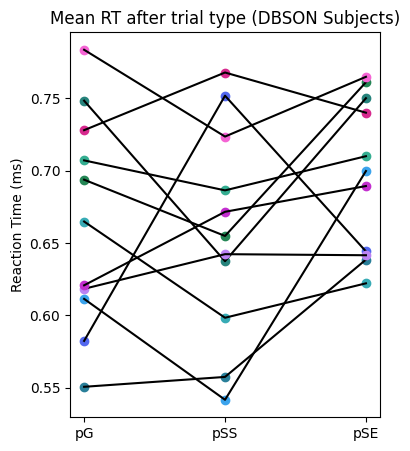

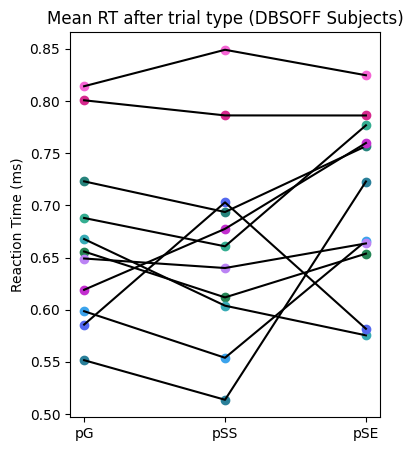

In [30]:
# separate by population
control_sub = [i for i in included_subjects if i.startswith('C')]
dbson_sub = [i for i in included_subjects if i.startswith('sub') and 'DBS ON' in i]
dbsoff_sub = [i for i in included_subjects if i.startswith('sub') and 'DBS OFF' in i]
pop_dict = {'control': control_sub, 'dbson': dbson_sub, 'dbsoff': dbsoff_sub}

for key, value in pop_dict.items():
    plt.figure(figsize=(4, 5))
    for subject in value:
        plt.plot([1], mean_pG_RT[subject], 'o', color= subject_colors[subject.split()[0] ])
        plt.plot([2], mean_pSS_RT[subject], 'o', color= subject_colors[subject.split()[0] ])
        plt.plot([3], mean_pSE_RT[subject], 'o', color= subject_colors[subject.split()[0] ])
        plt.plot([1, 2, 3], [mean_pG_RT[subject], mean_pSS_RT[subject], mean_pSE_RT[subject]], 'k-')  
    plt.xticks([1, 2, 3], ['pG', 'pSS', 'pSE'])
    plt.ylabel('Reaction Time (ms)')
    plt.title(f'Mean RT after trial type ({key.upper()} Subjects)')
    plt.show()

"Our observers exhibited a robust post-stop error slowing effect: RTs were significantly slower on pSE trials compared to pG trials (570 ± 127 vs. 528 ± 121 msec, mean ± SD; p < .001, paired t test; Figure 1C), suggesting that they implemented appropriate error monitoring and adjusted behaviors accordingly (Rabbit, 1966). Importantly, although observers were generally slower responding after an error, individual participants demonstrated significant trial-to-trial variation in pSE slowing"

Paired t-test between pSS and pSE trials for control subjects: t=2.30728018801059, p=0.03024692340635409


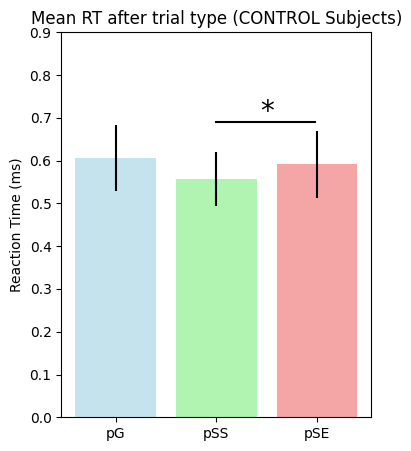

Paired t-test between pSS and pSE trials for dbson subjects: t=1.7524063520298068, p=0.05512543420183364


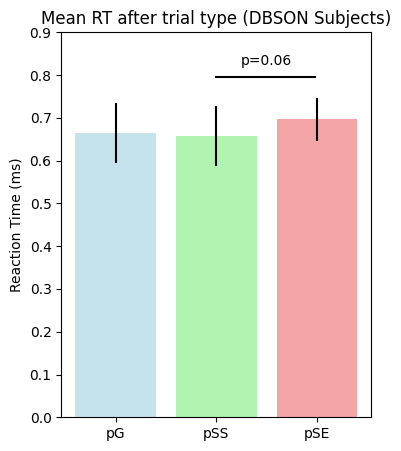

Paired t-test between pSS and pSE trials for dbsoff subjects: t=1.6134799580414525, p=0.06885762957355318


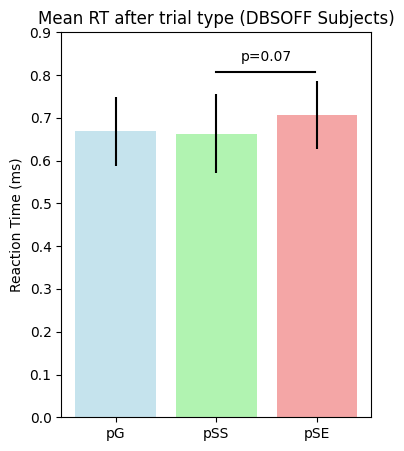

In [140]:
# do a barplot with mean and std error
# separate by population
control_sub = [i for i in included_subjects if i.startswith('C')]
dbson_sub = [i for i in included_subjects if i.startswith('sub') and 'DBS ON' in i]
dbsoff_sub = [i for i in included_subjects if i.startswith('sub') and 'DBS OFF' in i]
pop_dict = {'control': control_sub, 'dbson': dbson_sub, 'dbsoff': dbsoff_sub}

for key, value in pop_dict.items():
    plt.figure(figsize=(4, 5))
    mean_pG_RT_temp = []
    mean_pSS_RT_temp = []
    mean_pSE_RT_temp = []
    for subject in value:
        mean_pG_RT_temp.append(mean_pG_RT[subject])
        mean_pSS_RT_temp.append(mean_pSS_RT[subject])
        mean_pSE_RT_temp.append(mean_pSE_RT[subject])
    plt.bar([1, 2, 3], [np.mean(mean_pG_RT_temp), np.mean(mean_pSS_RT_temp), np.mean(mean_pSE_RT_temp)], 
            yerr=[np.std(mean_pG_RT_temp), np.std(mean_pSS_RT_temp), np.std(mean_pSE_RT_temp)],
            color=['lightblue', 'lightgreen', 'lightcoral'], alpha=0.7)
    # Hypothesis: H0: pES RT > pSS RT (post-error slowing)
    # paired t-test between pG and pSE trials:
    t_stat, p_value = ttest_rel(mean_pSE_RT_temp, mean_pSS_RT_temp, alternative = 'greater', nan_policy='omit')
    print(f'Paired t-test between pSS and pSE trials for {key} subjects: t={t_stat}, p={p_value}')
    # add significance asterisks
    if p_value < 0.05:
        plt.text(2.5, max(np.mean(mean_pSS_RT_temp), np.mean(mean_pSE_RT_temp)) + 0.09, '*', ha='center', va='bottom', fontsize=20)
        plt.axhline(y=max(np.mean(mean_pSS_RT_temp), np.mean(mean_pSE_RT_temp)) + 0.1, xmin=0.5, xmax=0.82, color='k')
    elif p_value < 0.01:
        plt.text(2.5, max(np.mean(mean_pSS_RT_temp), np.mean(mean_pSE_RT_temp)) + 0.09, '**', ha='center', va='bottom', fontsize=20)
        plt.axhline(y=max(np.mean(mean_pSS_RT_temp), np.mean(mean_pSE_RT_temp)) + 0.1, xmin=0.5, xmax=0.82, color='k')
    elif p_value < 0.001:
        plt.text(2.5, max(np.mean(mean_pSS_RT_temp), np.mean(mean_pSE_RT_temp)) + 0.09, '***', ha='center', va='bottom', fontsize=20)
        plt.axhline(y=max(np.mean(mean_pSS_RT_temp), np.mean(mean_pSE_RT_temp)) + 0.1, xmin=0.5, xmax=0.82, color='k')
    elif p_value < 0.1:
        plt.text(2.5, max(np.mean(mean_pSS_RT_temp), np.mean(mean_pSE_RT_temp)) + 0.12, f"p={p_value:.2f}", ha='center', va='bottom', fontsize=10)
        plt.axhline(y=max(np.mean(mean_pSS_RT_temp), np.mean(mean_pSE_RT_temp)) + 0.1, xmin=0.5, xmax=0.82, color='k')
    plt.xticks([1, 2, 3], ['pG', 'pSS', 'pSE'])
    plt.ylim(0, 0.9)
    plt.ylabel('Reaction Time (ms)')
    plt.title(f'Mean RT after trial type ({key.upper()} Subjects)')
    plt.show()

In [32]:
# compute group level mean statistics

group_stats = {}
for trial_type in trial_types:
    group_stats[trial_type] = {}
    for key, value in pop_dict.items():
        rt_after_successful = []
        rt_after_unsuccessful = []
        for subject in value:
            if np.isnan(subdivided_data_successful[subject][trial_type]['key_resp_experiment.rt'].mean()) or np.isnan(subdivided_data_unsuccessful[subject][trial_type]['key_resp_experiment.rt'].mean()):
                continue
            rt_after_successful.append(subdivided_data_successful[subject][trial_type]['key_resp_experiment.rt'].mean())
            rt_after_unsuccessful.append(subdivided_data_unsuccessful[subject][trial_type]['key_resp_experiment.rt'].mean())
        mean_rt_successful = np.nanmean(rt_after_successful)
        mean_rt_unsuccessful = np.nanmean(rt_after_unsuccessful)
        stat, p_value = ttest_rel(rt_after_successful, rt_after_unsuccessful)
        group_stats[trial_type][key] = {
            'mean_rt_after_successful': mean_rt_successful,
            'mean_rt_after_unsuccessful': mean_rt_unsuccessful,
            'ttest_stat': stat,
            'p_value': p_value
        }
group_stats

{'go_trial': {'control': {'mean_rt_after_successful': 0.6394464047080419,
   'mean_rt_after_unsuccessful': 0.6446005100909357,
   'ttest_stat': -0.1551673166205903,
   'p_value': 0.8817778292372589},
  'dbson': {'mean_rt_after_successful': 0.6893582354130828,
   'mean_rt_after_unsuccessful': 0.6777095368274776,
   'ttest_stat': 0.7141366318730789,
   'p_value': 0.49147523981904606},
  'dbsoff': {'mean_rt_after_successful': 0.6776644871244291,
   'mean_rt_after_unsuccessful': 0.6771062548335534,
   'ttest_stat': 0.03602161677124531,
   'p_value': 0.9719740406869337}},
 'go_fast_trial': {'control': {'mean_rt_after_successful': 0.48975540288153013,
   'mean_rt_after_unsuccessful': 0.49900217118528895,
   'ttest_stat': -0.4875218366811432,
   'p_value': 0.6431886838858359},
  'dbson': {'mean_rt_after_successful': 0.556564623001356,
   'mean_rt_after_unsuccessful': 0.5901446522992531,
   'ttest_stat': -1.1789427484719905,
   'p_value': 0.2686483036053116},
  'dbsoff': {'mean_rt_after_succes

In [ ]:
color_dict = {
    'dbson': '#20a39e', 
    'dbsoff': '#ef5b5b', 
    'control': '#ffba49', 
    'preop': '#8E7DBE',
    'Session 1': "#206ea1", 
    'Session 2': "#5FA363", 
    }

In [ ]:
# create a figure summarizing the results with violin plots
for trial_type in trial_types:
    plt.figure()
    summary_data = []
    labels = []
    for key, value in pop_dict.items():
        rt_after_successful = []
        rt_after_unsuccessful = []
        for subject in value:
            if np.isnan(subdivided_data_successful[subject][trial_type]['key_resp_experiment.rt'].mean()) or np.isnan(subdivided_data_unsuccessful[subject][trial_type]['key_resp_experiment.rt'].mean()):
                continue
            rt_after_successful.append(subdivided_data_successful[subject][trial_type]['key_resp_experiment.rt'].mean())
            rt_after_unsuccessful.append(subdivided_data_unsuccessful[subject][trial_type]['key_resp_experiment.rt'].mean())
        summary_data.append(rt_after_successful)
        labels.append(f'{key} - after successful')
        summary_data.append(rt_after_unsuccessful)
        labels.append(f'{key} - after unsuccessful')

    # color code based on population
    colors = [color_dict[key.lower()] for key in pop_dict.keys() for _ in (0, 1)]
    sns.violinplot(data=summary_data, palette=colors)
    plt.xticks(np.arange(len(labels)), labels, rotation=45)
    plt.ylabel('Reaction Time (ms)')
    plt.title(f'RT on {trial_type.replace("_", " ").upper()} after a successful or after an unsuccessful stop trial (All Subjects)')
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.colors as mc
import colorsys

def adjust_lightness(color, amount=1.0):
    try:
        c = mc.cnames[color]
    except KeyError:
        c = color
    r, g, b = mc.to_rgb(c)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    new_rgb = colorsys.hls_to_rgb(h, max(0, min(1, amount * l)), s)
    return new_rgb


In [ ]:
palette = {}

for group, base_color in color_dict.items():
    palette[(group, "successful")] = adjust_lightness(base_color, 1.3)   # lighter
    palette[(group, "unsuccessful")] = adjust_lightness(base_color, 0.7) # darker


In [ ]:
# do the same plots but normalize all RT to the mean RT of each subject
# first compute mean RT across each trial type for each subject
mean_rts = {}
for subject in included_subjects:
    subject_rts = {}
    subject_data = data[subject]
    for trial_type in trial_types:
        trials = subject_data[subject_data['trial_type'] == trial_type]
        subject_rts[trial_type] = trials['key_resp_experiment.rt'].mean()
    mean_rts[subject] = subject_rts

# then normalize the RTs after successful and unsuccessful stop trials
normalized_subdivided_data_successful = {}
normalized_subdivided_data_unsuccessful = {}
for subject in included_subjects:
    normalized_successful = {}
    normalized_unsuccessful = {}
    for trial_type in trial_types:
        successful_rts = subdivided_data_successful[subject][trial_type]['key_resp_experiment.rt'] - mean_rts[subject][trial_type]
        unsuccessful_rts = subdivided_data_unsuccessful[subject][trial_type]['key_resp_experiment.rt'] - mean_rts[subject][trial_type]
        normalized_successful[trial_type] = successful_rts
        normalized_unsuccessful[trial_type] = unsuccessful_rts
    normalized_subdivided_data_successful[subject] = normalized_successful
    normalized_subdivided_data_unsuccessful[subject] = normalized_unsuccessful

# now recreate the violin plots with normalized RTs
for trial_type in trial_types:
    plt.figure()
    summary_data = []
    labels = []
    for key, value in pop_dict.items():
        rt_after_successful = []
        rt_after_unsuccessful = []
        for subject in value:
            if np.isnan(normalized_subdivided_data_successful[subject][trial_type].mean()) or np.isnan(normalized_subdivided_data_unsuccessful[subject][trial_type].mean()):
                continue
            rt_after_successful.append(normalized_subdivided_data_successful[subject][trial_type].mean())
            rt_after_unsuccessful.append(normalized_subdivided_data_unsuccessful[subject][trial_type].mean())
        summary_data.append(rt_after_successful)
        labels.append(f'{key} - after successful')
        summary_data.append(rt_after_unsuccessful)
        labels.append(f'{key} - after unsuccessful')

    # color code based on population
    colors = [color_dict[key.lower()] for key in pop_dict.keys() for _ in (0, 1)]
    sns.violinplot(data=summary_data, palette=colors)
    plt.xticks(np.arange(len(labels)), labels, rotation=45)
    plt.ylabel('Normalized Reaction Time')
    plt.title(f'Normalized RT on {trial_type.replace("_", " ").upper()} after a successful or after an unsuccessful stop trial (All Subjects)')
    plt.tight_layout()
    plt.show()

# # plot normalized rt after successful and unsuccessful stop trials
# for trial_type in trial_types:
#     for key, value in pop_dict.items():
#         rt_after_successful = []
#         rt_after_unsuccessful = []
#         for subject in value:
#             rt_after_successful.append(normalized_subdivided_data_successful[subject][trial_type].mean())
#             rt_after_unsuccessful.append(normalized_subdivided_data_unsuccessful[subject][trial_type].mean())
#         plt.figure()
#         plt.plot([1]*len(value), rt_after_successful, 'o', label='after successful stop')
#         plt.plot([2]*len(value), rt_after_unsuccessful, 'o', label='after unsuccessful stop')
#         plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
#         for i in range(len(value)):
#             plt.plot([1, 2], [rt_after_successful[i], rt_after_unsuccessful[i]], 'k-')  
#         plt.xticks([1, 2], ['after successful stop', 'after unsuccessful stop'])
#         plt.ylabel('Normalized Reaction Time')
#         plt.title(f'Normalized RT on {trial_type.replace("_", " ").upper()} after a successful or after an unsuccessful stop trial ({key.upper()} Subjects)')
#         plt.legend()
#         plt.show()

In [ ]:
import pandas as pd

rows = []

for subject in included_subjects:
    # find subject group
    group = None
    for key, subs in pop_dict.items():
        if subject in subs:
            group = key.lower()
            break

    for trial_type in trial_types:
        # successful
        vals = normalized_subdivided_data_successful[subject][trial_type].dropna()
        for v in vals:
            rows.append({
                "subject": subject,
                "group": group,
                "trial_type": trial_type,
                "prev_stop": "successful",
                "rt_norm": v
            })

        # unsuccessful
        vals = normalized_subdivided_data_unsuccessful[subject][trial_type].dropna()
        for v in vals:
            rows.append({
                "subject": subject,
                "group": group,
                "trial_type": trial_type,
                "prev_stop": "unsuccessful",
                "rt_norm": v
            })

df_long = pd.DataFrame(rows)
df_long["group_prev"] = list(zip(df_long["group"], df_long["prev_stop"]))

In [ ]:
for trial_type in trial_types:
    plt.figure(figsize=(9, 5))

    df_plot = df_long[df_long["trial_type"] == trial_type]

    sns.violinplot(
        data=df_plot,
        x="group",
        y="rt_norm",
        hue="group_prev",
        split=True,
        inner="quartile",
        palette=palette,
        order=["control", "dbson", "dbsoff"]
    )

    plt.ylabel("Normalized Reaction Time (ms)")
    plt.xlabel("")
    plt.title(f"Normalized RT – {trial_type.replace('_', ' ').upper()}")

    # Clean legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=adjust_lightness(color_dict[g], 1.3), label=f"{g} – successful")
        for g in ["control", "dbson", "dbsoff"]
    ] + [
        Patch(facecolor=adjust_lightness(color_dict[g], 0.7), label=f"{g} – unsuccessful")
        for g in ["control", "dbson", "dbsoff"]
    ]

    plt.legend(handles=legend_elements, title="Group / Previous stop trial",
               bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()


In [ ]:
for trial_type in trial_types:
    plt.figure(figsize=(7, 5))

    df_plot = df_long[df_long["trial_type"] == trial_type]

    sns.violinplot(
        data=df_plot,
        x="group",
        y="rt_norm",
        hue="prev_stop",
        split=True,
        inner="quartile",
        palette={
            "successful": "#4C72B0",
            "unsuccessful": "#DD8452"
        }
    )

    plt.ylabel("Normalized Reaction Time (ms)")
    plt.xlabel("")
    plt.title(f"Normalized RT – {trial_type.replace('_', ' ').upper()}")
    plt.legend(title="Previous stop trial")

    plt.tight_layout()
    plt.show()
